# Developing the Threat Index for Skiing Conditions and Comfort

## Factors we took into account for our threat index

#### What is the focus for the threat index?
We are focusing on an application-specific impact for our threat index where weather impacts skiing conditions.This threat index focus is more application rather than a specific weather phenomenom because we aren't just looking at a single winter storm or other phenomenom, we're looking at how specific weather conditions combined make for optimal days to enjoy skiing in the Northeast. While many indices focus on the severity of a storm, this index focuses on recreational viability. In the Northeast, conditions are notorious for being either really harsh and volatile with ice to being extremely warm and slushy slow within just a couple of days. This index synthesizes Numerical Weather Prediction (NWP data) which accounts for both the quality of conditions and the physical comfort of the skier. 

#### What is our target audience?
Our target audience would be the general public who enjoy the outdoor sport of skiing/snowboarding. Essentially, any person who wants to head up to a mountain in the Northeast that offers the sport, and needs to see if all factors considered would be an enjoyable day worth skiing. This demographic is sensitive to the safety and enjoyment of the skier by avoiding frostbite, dangerous wind chills, melting days, or rainy days. In addition, our index places high value on the amount of snow in order to maximize skiing enjoyability, as this sport can be expensive. Lastly, our index makes sure to take into account the trail visibility by weighting the cloud cover in order to find which area will have the best possible ski conditions. Having high cloud cover can make it difficult to see trails, so this safety precaution is built into our programming.


#### What is the appropriate scale or range for the index?
Our scale would be from 0-100. Any area with zeroes based off our colorbars would mean conditions are not at all optimal for skiing posing safety risks by extreme cold/temperatures above freezing or total snowmelt/rain. Any area with one-hundred would mean perfect conditions and all variables align together. Specifically, our audience would be paying attention to areas where the scale ranges from 80-100, because this would indicate fresh snow, light winds, and temperatures cold enough for snow to remain without it being too cold to ski for a prolonged period of time. Anywhere in the 50-70 range is safe and skiiable but may involve icy patches on the mountains or high cloud cover. Examples of sub-optimal conditions would appear in the 1-49 range where thin snow cover, rain, and/or high winds might affect lift operations and skiing enjoyability. 

#### NWP model variables
The variables we'll be working with are, temperature(2m), total precipitation, categorial snow, wind speed, and total cloud cover. Below, to create a productive function, we weigh these variables based on the impact to user experience. 

## How we developed our threat index: 

- Values Ranging from: 0 to 100
- 0 = no skiing (mountain is closed)
- 100 = best possible conditions for skiing

Best possible conditions:
- temperature between 20 - 32 F
- less than 50% cloud cover
- wind speed less than 50 mph
- total snow precipitation from 1-6 in 

Variables Weighting for the Index:
- temperature: 40%
- clouds: 10%
- wind: 20%
- total snow precipitation: 30%

Temperature contribution:
- 0 when T > 50 F
- 1 when 20 <= T <= 32
- 0 when T < 0
- function slope from 0 - 20 and 32 - 50


#### Function for temp distribution:

y = 0 {x < 0}

y = (1 - ((20 - x)/20)^2) {0 <= x < 20}

y = 1 {20 <= x <= 32}

y = (1 - ((x - 32)/18)^2) {32 < x <= 50}

y = 0 {x > 50}

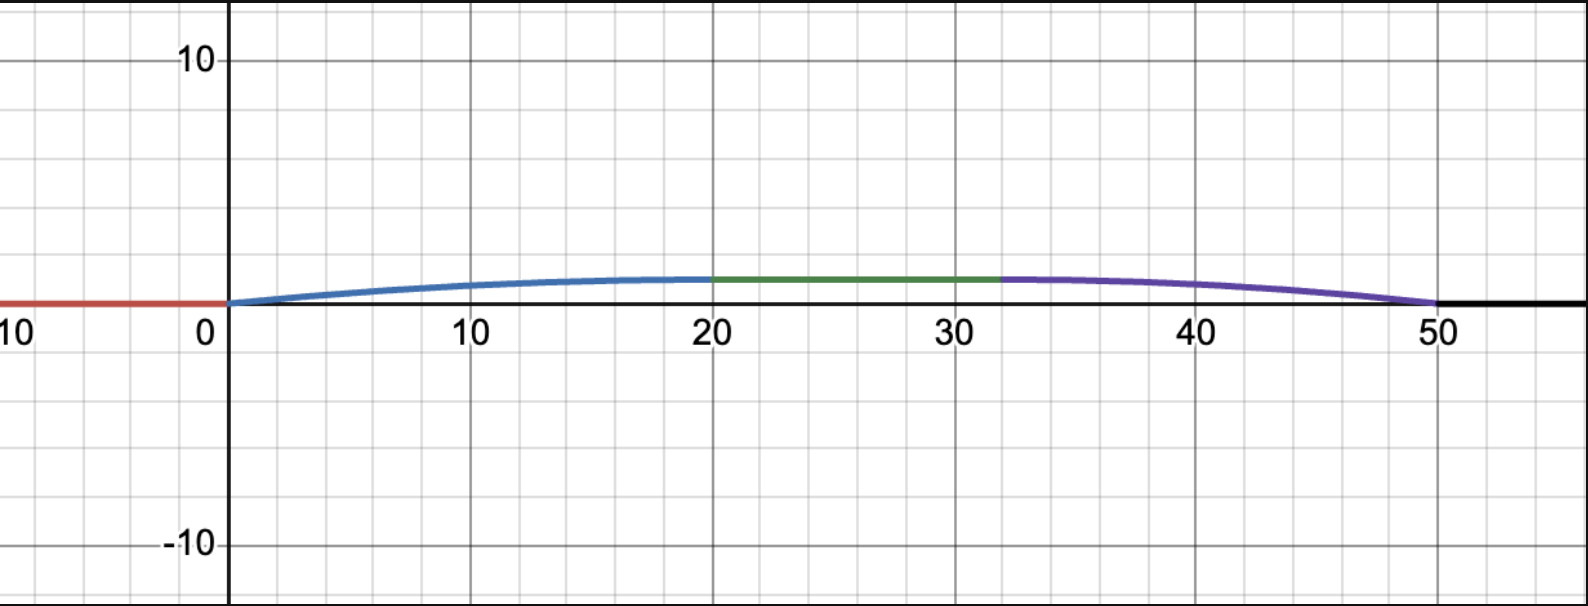

#### Function for cloud cover:

y = (0.01x + 0.5){0 ≤ x ≤ 50}

y = (-0.01x + 1.5){50 ≤ x ≤ 100}

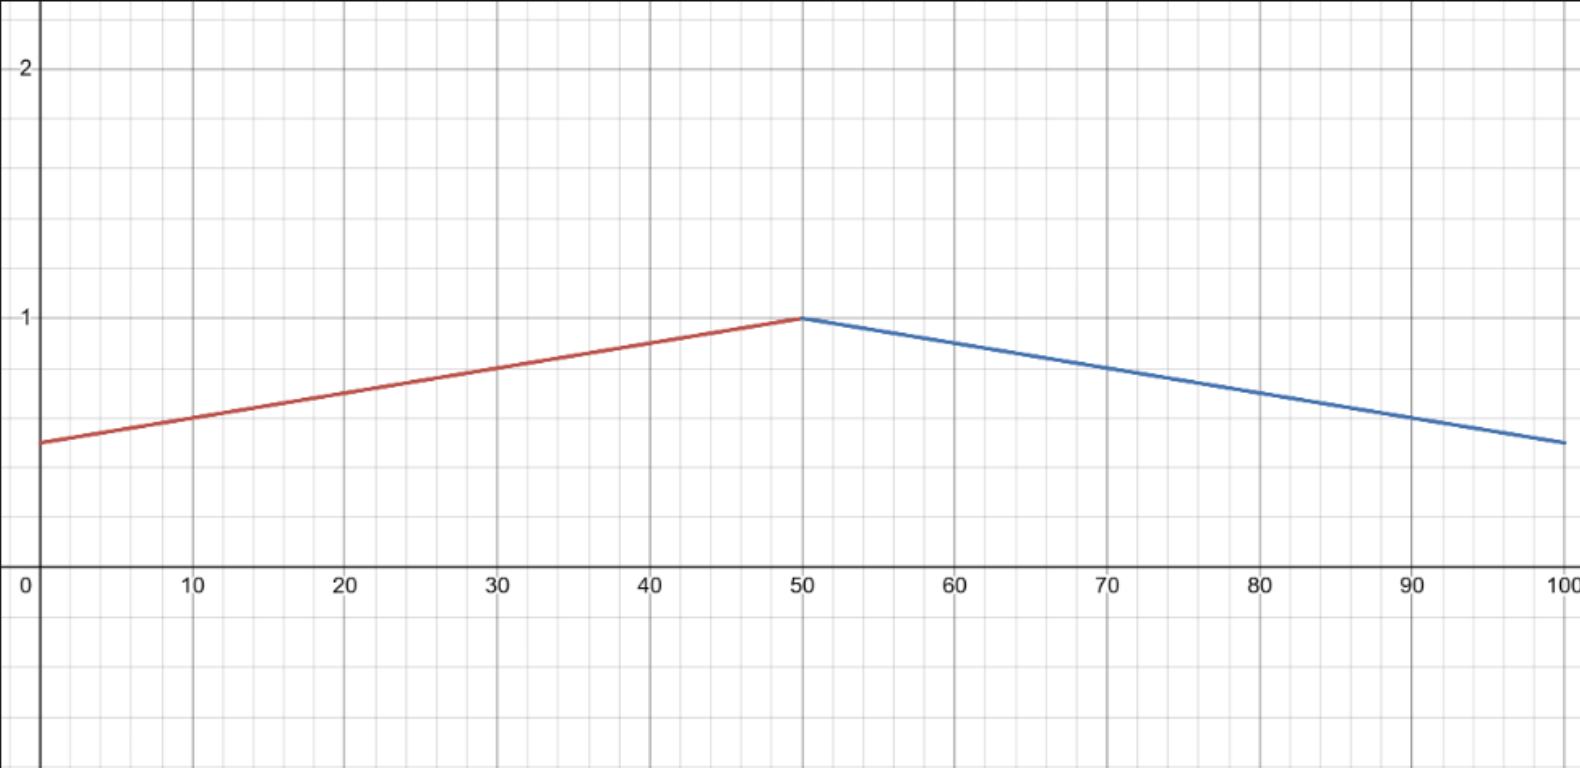 

#### Function for wind speed: 

y = (-1/50)x -1 {0 < x < 50}

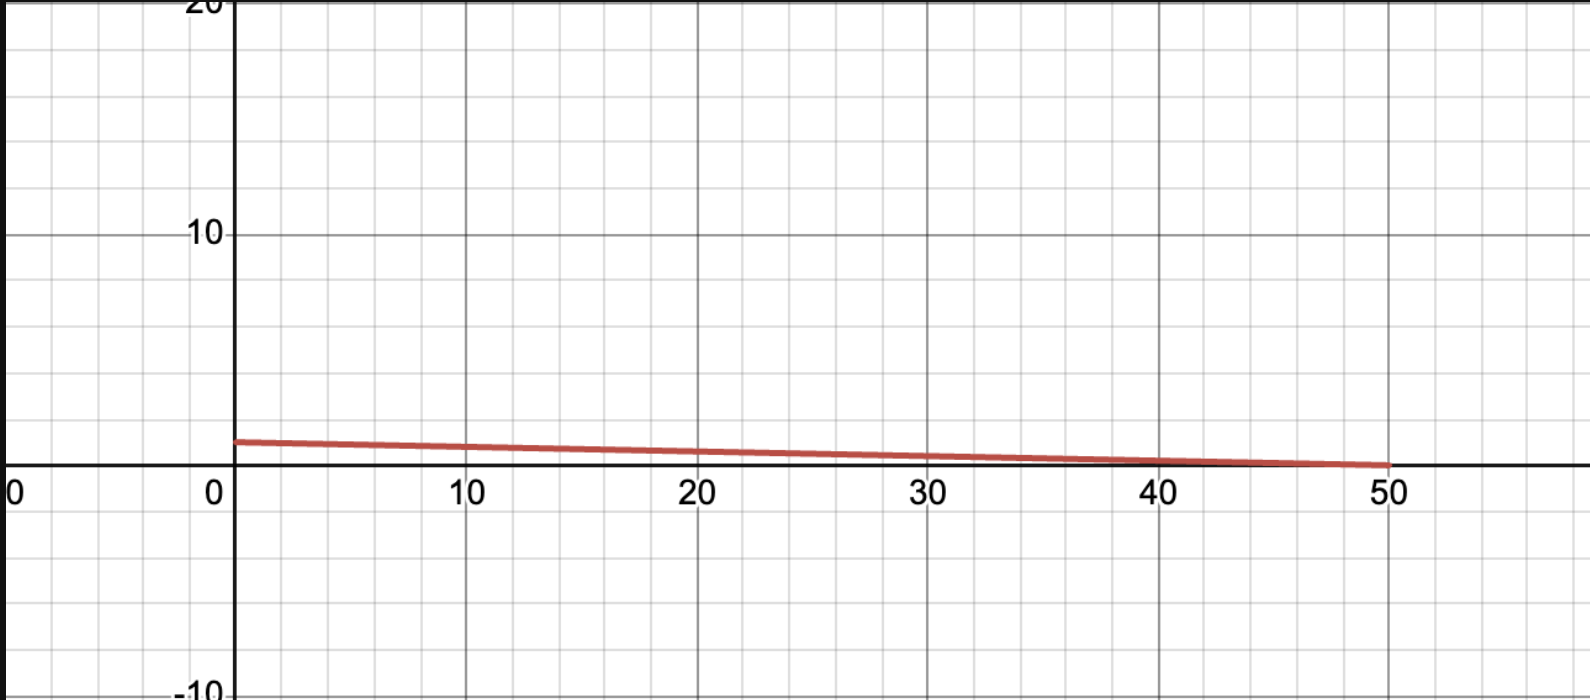

#### Function for snow depth:

y = 1 {x > 6}

y = ((1/6)(x)) {0 <= x <= 6}

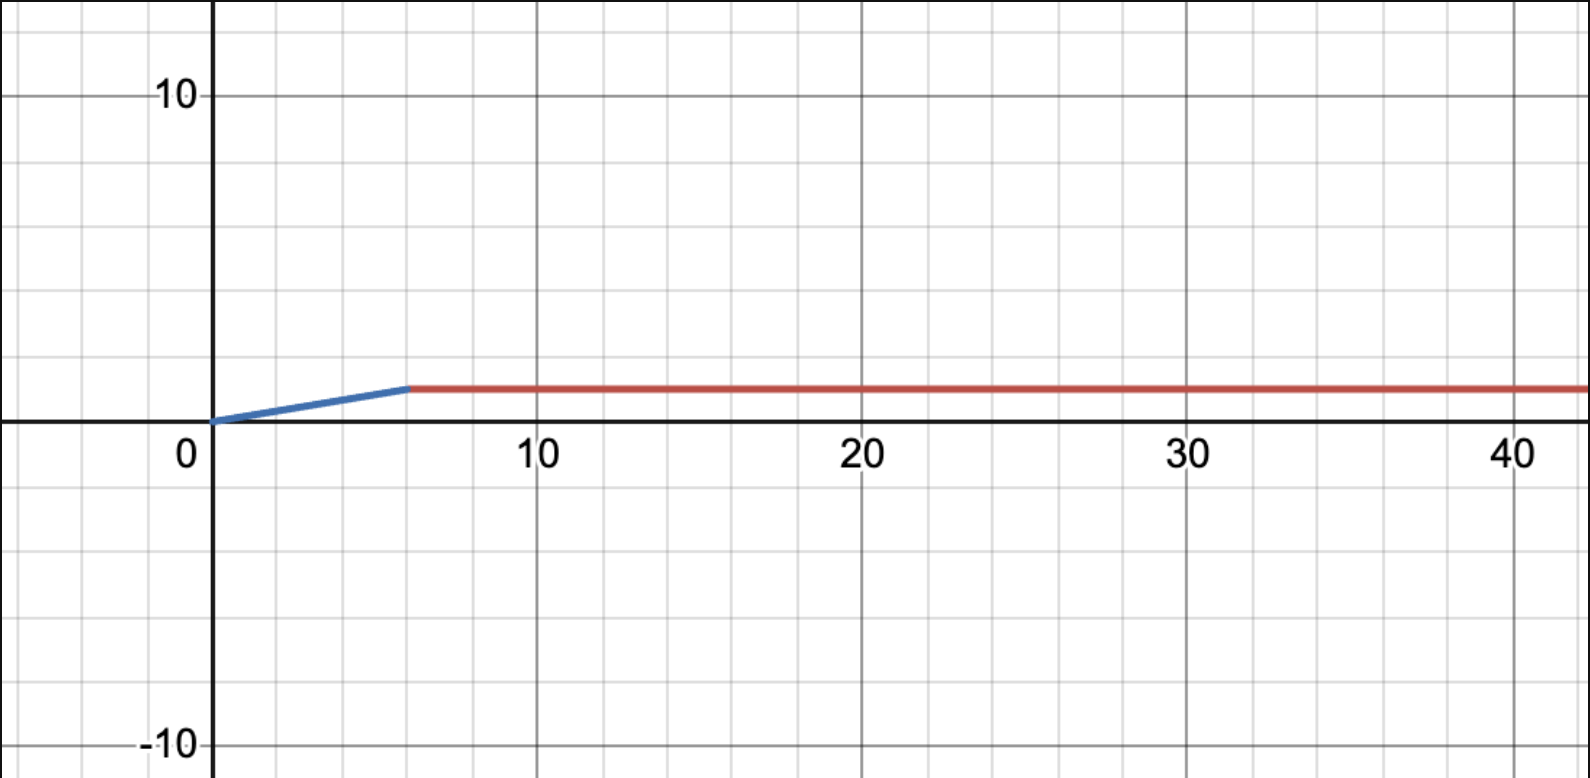 


### Importing functions needed to develop threat index

In [1]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs, cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import xarray as xr
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

### Importing our Datasets

In [2]:
ds = xr.open_dataset('gfs.nc')

sh: 1: getfattr: not found


In [3]:
ds

<xarray.Dataset> Size: 7MB
Dimensions:            (valid_time: 40, latitude: 81, longitude: 81)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 320B 2026-02-22 ... 2026-0...
  * latitude           (latitude) float64 648B 55.0 54.75 54.5 ... 35.25 35.0
  * longitude          (longitude) float64 648B 280.0 280.2 ... 299.8 300.0
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 320B ...
    surface            float64 8B ...
    heightAboveGround  float64 8B ...
    atmosphere         float64 8B ...
Data variables:
    sde                (valid_time, latitude, longitude) float32 1MB ...
    t2m                (valid_time, latitude, longitude) float32 1MB ...
    tp                 (valid_time, latitude, longitude) float32 1MB ...
    tcc                (valid_time, latitude, longitude) float32 1MB ...
    u10                (valid_time, latitude, longitude) float32 1MB ...
    v10                (valid_time, latitude, longitude) float32 1MB ...
    csnow              (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-23T17:15 GRIB to CDM+CF via cfgrib-0.9.1...

#### Setting a time to pull our variable values from

In [4]:
chosen_hour = 6
s_ds = ds.isel(valid_time = chosen_hour)   

### Selecting data from the northeast

In [ ]:
ds_ne = s_ds.sel(latitude = slice(50,40), longitude = slice(280, 300))  

## Pulling our variables and converting them to the designated units

In [5]:

t2m_f = (ds_ne['t2m'].values-273.15)* (9/5) + 32 #Fahrenheit

tcc = ds_ne['tcc'].values #%

u = ds_ne['u10'].values * 2.23694 
v = ds_ne['v10'].values * 2.23694 
wind = np.sqrt(u**2 + v**2) #mph

sde = ds_ne['sde'].values * 100 #Cm

csnow = ds_ne['csnow'].values #catagorial snow

tp = ds_ne['tp'].values * 2.54 #in inches and changed to snow from liquid using ratio 10:1

lat = ds_ne.latitude.values
lon = ds_ne.longitude.values

## Extracting values for 6 hr interval for the total snow precip. 

In [6]:

tp_chosenhr= ds.tp.isel(valid_time= chosen_hour).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_prevhr = ds.tp.isel(valid_time= chosen_hour - 1).sel(latitude = slice(50,40), longitude = slice(280, 300)).values
tp_interval = tp_chosenhr - tp_prevhr
tp_interval = tp_interval * 0.03937 * 10 #in inches and changed to snow from liquid using ratio 10:1

### Selecting valid time and initial time from the dataset

In [ ]:
# Contribution: 
t2m_contribution = np.zeros_like(t2m_f)
#getting valid time and initial time from the dataset
valid_time = datetime.strptime(str(ds.valid_time.values[chosen_hour])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y") #valid time for the plot
initial_time = datetime.strptime(str(ds.valid_time.values[0])[:16], "%Y-%m-%dT%H:%M").strftime("%H:%M UTC %b %d %Y")


## Formatting all of the Contribution Variables for the Threat Index

### 2 Meter Temperature Variable
##### This will:
- Get values of Temperature between 0-20 to increase linearly for contribution to the index
- Get values of Temperature between 20-32 to be the highest value for the index
- Get values of Temperature between 32-50 to decrease linearly for contribution to the index
- Get values of Temperature greater than fifty to be the lowest value for the index
- Then graph the temperature contribution for the selected timestep

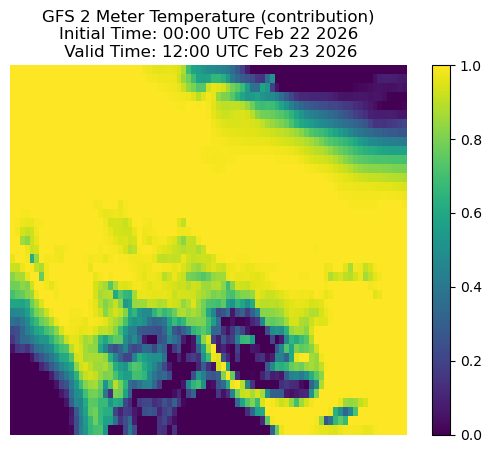

In [7]:

# 0 <= T < 20 : increase from 0 to 1
mask = (t2m_f >= 0) & (t2m_f < 20)
t2m_contribution[mask] = (1 - ((20 - t2m_f[mask])/20)**2)

# 20 <= T <= 32 : contribution = 1
mask = (t2m_f >= 20) & (t2m_f <= 32)
t2m_contribution[mask] = 1.0

# 32 < T < 50 : decrease from 1 to 0.5
mask = (t2m_f > 32) & (t2m_f < 50)
t2m_contribution[mask] = (1 - ((t2m_f[mask] - 32)/18)**2)

# T >- 50 : contribution = 0
mask = t2m_f >= 50
t2m_contribution[mask] = 0


# Plotting: 
plt.pcolormesh(lon, lat, np.flipud(t2m_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS 2 Meter Temperature (contribution)\nInitial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Total Cloud Cover Contribution Variable

##### This will:
- Get values of Cloud Cover between 0-50 to increase linearly for contribution to the index
- Get values of Temperature between 50-100 to decrease linearly for contribution to the index
- Then graph the cloud cover contribution for the selected timestep

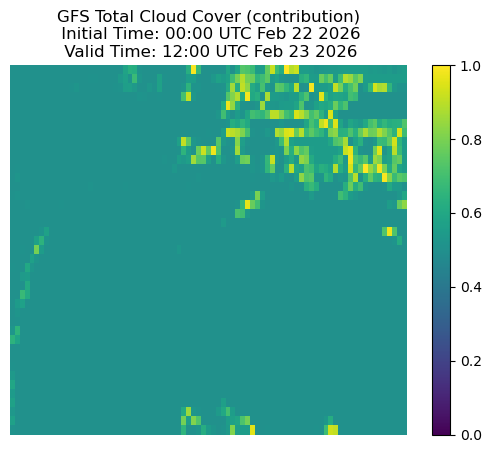

In [8]:
# Contribution:
tcc_contribution = np.zeros_like(tcc)

# 0 <= tcc <= 50 : linear increase from 0% to 50%
mask = (tcc >= 0) & (tcc <= 50)
tcc_contribution[mask] = (0.01)*(tcc[mask]) + 0.5

# 50 < tcc <= 100 : linear decrease from 50% tp 100%
mask = (tcc > 50)
tcc_contribution[mask] = (-0.01)*(tcc[mask]) + 1.5

# Plotting:
plt.pcolormesh(np.flipud(tcc_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Total Cloud Cover (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Wind Contribution Variable

##### This will:
- Get values of Wind speed between 0-50 to increase linearly for contribution to the index
- Get values of Wind speed greater than 50 to be the lowest values for the index
- Then graph the wind speed contribution for the selected timestep

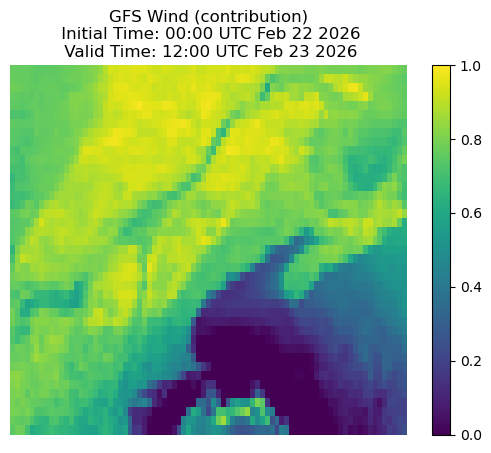

In [9]:
# Contribution:
wind_contribution = np.zeros_like(wind)

# 0 <= T <= 50 : increase
mask = (wind >= 0) & (wind <= 50)
wind_contribution[mask] = ((-1/50)*(wind[mask])) + 1

#Plotting: 
plt.pcolormesh(np.flipud(wind_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Wind (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

#### Total Snow Precipitation Contribution Variable 
##### This will:
- Only select values of precipitation where there is snow
- Get values of Snow Precipitation between 0-6 inches to increase linearly for contribution to the index
- Then graph the snow precipitation contribution for the selected timestep

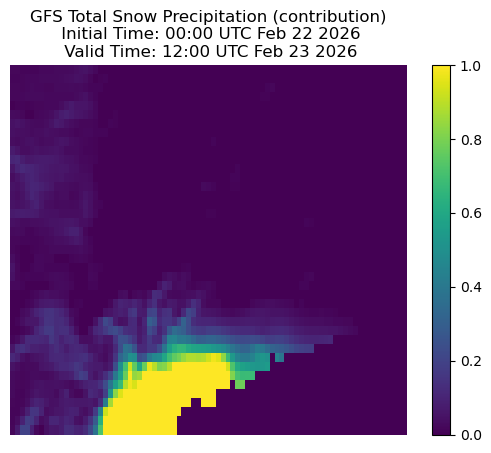

In [10]:
#Choosing Where it's Snowing and not Raining
tp_snow_only = np.where(csnow == 1, tp_interval, 0)
tp_contribution = np.zeros_like(tp_snow_only)

#Masking for total precip 
mask = (tp_snow_only >= 0) & (tp_snow_only <= 6)
tp_contribution[mask] = ((1/6)*(tp_snow_only[mask]))
mask = (tp_snow_only > 6)
tp_contribution[mask] = 1

# plotting where it is snowing
plt.pcolormesh(np.flipud(tp_contribution), vmin = 0, vmax = 1)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Total Snow Precipitation (contribution)\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()

## Final Threat Index Equation

With the variables weighting for the index being:
- temperature: 40%
- clouds: 10%
- wind: 20%
- total snow precipitation: 30%

And then plotting the threat index below

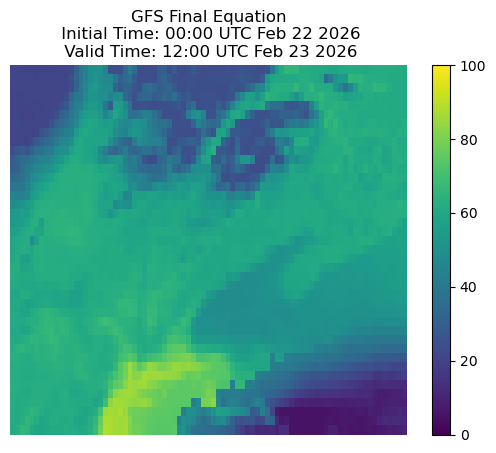

In [11]:

PUI = (t2m_contribution*0.4 + tcc_contribution*0.1 + wind_contribution*0.2 + tp_contribution*0.3)*100

# Plotting the Final Equation (threat index): 
plt.pcolormesh(np.flipud(PUI), vmin = 0, vmax = 100)
plt.colorbar()
plt.xlabel("Longitude")
plt.ylabel("Latidude")
plt.axis('off')
plt.title(f"GFS Final Equation\n Initial Time: {initial_time}\n Valid Time: {valid_time}")
plt.show()